# 计算态演化

## 薛定谔演化

### 格式1：使用函数 `evolve_and_measure`


In [ ]:
import quante as qt
import numpy as np
op = qt.generate.operas.boson
L = 1
basis = qt.generate.basis.quspin_boson_basis(L=L, sps=2)

Ham = op.builder()
for l in range(L):
    # Ham += "+-+-", [l, l, l+1, l+1], 1.0,
    Ham += "n", [l], 1.0,
Ham = Ham.build()

ham = Ham.to_matrix(basis)
ham

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

100%|##########| 200/200 [00:00<00:00, 497.05it/s]


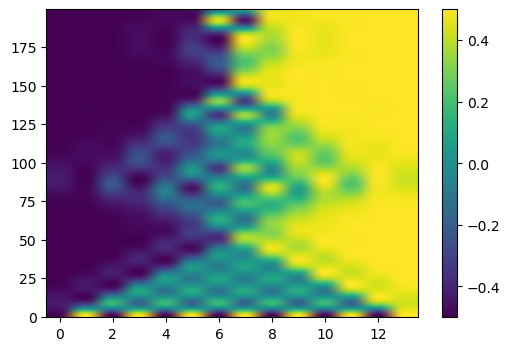

In [40]:
from unittest import result
import quante as qt
import numpy as np
op = qt.generate.operas.spin

L = 14
basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)

# Model
J, γ = 1., 0.5
builder = op.builder()
for l in range(L-1):
    builder += '+-', [l+1, l], 1/2 * (J + γ),
    builder += '+-', [l, l+1], 1/2 * (J - γ),
ham = builder.build()
hammat = ham.to_matrix(basis=basis, sparse=True)

tlist = np.linspace(0, 40, 200)
init_state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
# init_state = qt.generate.state.product_state("1"+"0"*(L-1), Nup=1)
obsoper = [op.z(i).to_matrix(basis=basis, sparse=True) for i in range(L)]
# obsoper = [op.z(0).to_matrix(basis=basis, sparse=True), 
#            op.z(1).to_matrix(basis=basis, sparse=True)]  # todo dense matrix

result_time_obs = qt.linalg.evolve_and_measure(
    hammat, init_state, tlist,
    measure=obsoper,
    normalize=True,
    method="mul-cpu"
)
result_time_obs.shape
result_time_obs
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
plt.imshow(result_time_obs, aspect='auto', origin='lower')
plt.colorbar()

### 格式2：使用函数 `EvolveEngine().measure()`

可以调用的方法不包含 `eig`

array([[ 0.5       ,  0.49486073,  0.47960136,  0.45469179,  0.4208973 ,  0.37925233,  0.33102523,  0.27767502,  0.22080193,  0.16209336,  0.10326729,  0.04601509, -0.00805413, -0.05746578, -0.10092665, -0.13736496, -0.16596212, -0.18617517, -0.19774929, -0.20072006, -0.19540554, -0.18238865, -0.1624906 , -0.13673649, -0.10631444, -0.07252975, -0.03675585, -0.00038369,  0.03522847,  0.06880321,  0.0991884 ,  0.12539629,  0.14663604,  0.16233843,  0.17217203,  0.17605022,  0.17412876,  0.1667942 ,  0.15464343,  0.13845519,  0.11915471,  0.0977728 ,  0.07540102,  0.05314478,  0.03207624,  0.01318883, -0.00264448, -0.01470768, -0.0224714 , -0.02561444, -0.02403646, -0.01786113, -0.00742985,  0.00671378,  0.02384797,  0.04310411,  0.06350422,  0.08400279,  0.10353132,  0.12104358,  0.13556   ,  0.14620909,  0.15226454,  0.15317653,  0.14859598,  0.13839103,  0.12265507,  0.10170613,  0.07607771,  0.04650138,  0.01388179, -0.02073491, -0.05619826, -0.09129483, -0.1247924 , -0.15548527, -0.1

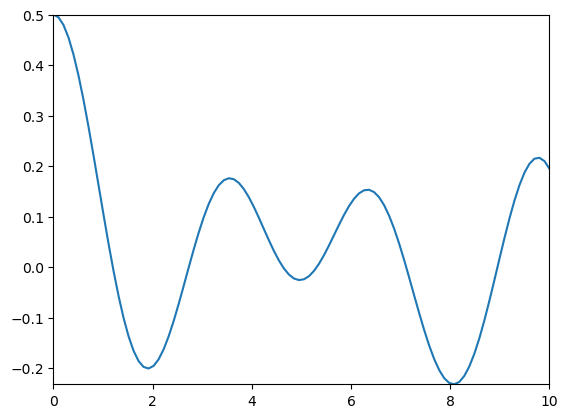

In [4]:
import numpy as np
import quante as qt
op = qt.generate.operas.spin
tlist = np.linspace(0, 10, 100)

# Model
L=10
J, γ = 1., 0.1
builder = op.builder()
for l in range(L-1):
    builder += "+-", [l+1, l], (J+γ)/2
    builder += "+-", [l, l+1], (J-γ)/2
ham = builder.build()

basis = qt.generate.basis.spin_basis(L=L)
hammat = ham.to_matrix(basis=basis, sparse=True)

# Observation
obsmatlist = [op.z(L//2).to_matrix(basis, sparse=True)]
init_state = qt.generate.state.neel(L=L, down_first=True)

# Plot
evolve_engine = qt.linalg.EvolveEngine(
    hammat, init_state, ts=tlist, normalize=True
)
res = evolve_engine.plot_measure(obsmatlist)  # 使用 plot_measure 可以直接绘图
res

不同方法的结果对比

In [7]:
import quante as qt
import numpy as np
op = qt.generate.operas.spin

L = 10
basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)

# Model
J, γ = 1., 0.
builder = op.builder()
for l in range(L-1):
    builder += '+-', [l+1, l], 1/2 * (J + γ),
    builder += '+-', [l, l+1], 1/2 * (J - γ),
ham = builder.build()
hammat = ham.to_matrix(basis=basis, sparse=False)

tlist = np.linspace(0, 10, 200)
init_state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
obsoper = [op.z(i).to_matrix(basis=basis, sparse=True) for i in range(L)]

res = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='eig-cpu')
# res1 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='eig-cuda:0')
res2 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='mul-cpu')
# res3 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='mul-cuda:0')
res4 = qt.linalg.evolve_and_measure(hammat, init_state, tlist, measure=obsoper, method='RK45')
# list(map(np.linalg.norm, [res1 - res, res2 - res, res3 - res, res4 - res]))

100%|##########| 200/200 [00:00<00:00, 2227.49it/s]


## 主方程演化

PHYSICAL REVIEW LETTERS 127, 070402 (2021)

$$
    \mathcal{L}(\rho) = -i [H, \rho] + \sum_{l} L_l \rho L_l^{\dagger} - \frac{1}{2} \sum_{l} (L_l^{\dagger} L_l \rho + \rho L_l^{\dagger} L_l)
$$

/Users/dzwang/anaconda3/envs/dzwang/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/dzwang/anaconda3/envs/dzwang/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


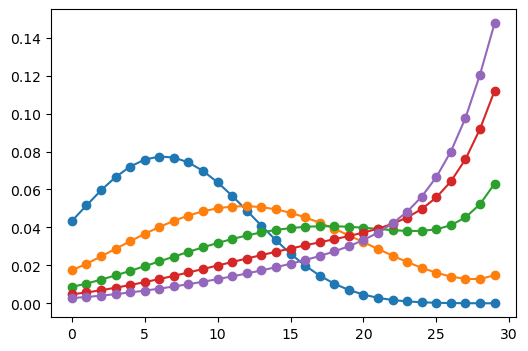

In [16]:
import quante as qt
import numpy as np

op = qt.generate.operas.spin

L = 30
J = 1.
gamma_R = 1.0
gamma_L = 0.5

ham = op.builder()
for i in range(L-1):
    ham += "+-", [i+1, i], -J
    ham += "+-", [i, i+1], -J
ham = ham.build()

basis = qt.generate.basis.spin_basis(L=L, Nup=1)
hammat = ham.to_matrix(basis=basis, sparse=True)

Lindblad_R = [np.sqrt(gamma_R) * op.pm(i+1,i).to_matrix(basis=basis, sparse=True) for i in range(L-1)]
Lindblad_L = [np.sqrt(gamma_L) * op.pm(i,i+1).to_matrix(basis=basis, sparse=True) for i in range(L-1)]
particle_number = [op.n(i).to_matrix(basis=basis, sparse=True) for i in range(L)]

state = qt.generate.state.product_state('1'+'0'*(L-1), Nup=1)
rhoinit = np.outer(state, state)

lvn = qt.linalg.Liouvillian(hammat, Lindblad_R + Lindblad_L)
res = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='eig-cpu'
)
res

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(res.T, "o-");

不同方法的对比

In [16]:
lvn.default_mul = 'sp'

res1 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='eig-cuda:0'
)

res2 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='mul-cpu'
)

res3 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='mul-cuda:0'
)

res4 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='RK45'
)

lvn.default_mul = 'lo'

res5 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='mul-cpu'
)

res6 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='RK45'
)

list(map(np.linalg.norm, [res1 - res, res2 - res, res3 - res, res4 - res, res5 - res, res6 - res]))

  0%|          | 0/5 [00:00<?, ?it/s]e:\hzhu\onedrive\library\quante\quante\torch_utils\linalg\sparse.py:51: UserWarning: cupy is not avilable, use scipy
  warn("cupy is not avilable, use scipy")
e:\hzhu\onedrive\library\quante\quante\torch_utils\linalg\sparse.py:143: UserWarning: No module named 'cupyx', use scipy
  warn(str(e) + ", use scipy")
100%|##########| 5/5 [00:10<00:00,  2.07s/it]


[np.float64(2.5241927749371035e-14),
 np.float64(4.379398099592581e-14),
 np.float64(4.5680907553659434e-14),
 np.float64(8.670935108900701e-11),
 np.float64(4.458819370589601e-14),
 np.float64(8.663061993575422e-11)]

后面两种方法都使用 LinearOperator，如果使用 dense matrix 计算会快一些

In [17]:
lvn = qt.linalg.Liouvillian(hammat, [ld.toarray() for ld in Lindblad_R + Lindblad_L])
lvn.default_mul = 'lo'
res3 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='mul-cpu'
)

res4 = qt.linalg.evolve_and_measure(
    lvn, rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='RK45'
)

list(map(np.linalg.norm, [ res3 - res, res4 - res]))

100%|##########| 5/5 [00:02<00:00,  2.45it/s]


[np.float64(4.460031632440544e-14), np.float64(8.699891755889444e-11)]

稳态

In [11]:
lvn = qt.linalg.Liouvillian(hammat, Lindblad_R + Lindblad_L)
res = lvn.steady_state()

qt.linalg.expect(particle_number, res, isdm=True)

array([0.00022988, 0.0002796 , 0.00035408, 0.00044866, 0.00056866, 0.0007208 , 0.00091366, 0.00115814, 0.00146803, 0.00186085, 0.00235878, 0.00298994, 0.00378998, 0.00480411, 0.00608959, 0.00771904, 0.00978449, 0.01240259, 0.01572123, 0.01992778, 0.02525976, 0.03201805, 0.04058375, 0.051439  , 0.0651927 , 0.08261014, 0.10464141, 0.13241707, 0.16698079, 0.20526746])

## 不同方法的 benchmark

In [19]:
import quante as qt
L = 12
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)
state = qt.generate.state.random(basis.Ns, seed=42)
qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, herm=True)

array([[[ 0.00335624+0.00606165j],
        [-0.01145467+0.0090065j ],
        [ 0.00826567+0.0048053j ],
        ...,
        [-0.01305153+0.00220341j],
        [ 0.00607938+0.00661749j],
        [-0.01943596+0.01879979j]],

       [[ 0.0048898 +0.00490894j],
        [-0.00893959+0.01087129j],
        [ 0.01002091+0.00476051j],
        ...,
        [-0.01273198+0.00414389j],
        [ 0.00764766+0.00570824j],
        [-0.01353566+0.02340886j]],

       [[ 0.00604849+0.00337989j],
        [-0.00609528+0.01202976j],
        [ 0.01195179+0.00416268j],
        ...,
        [-0.01204725+0.00597486j],
        [ 0.00906296+0.00443277j],
        [-0.00659764+0.02622327j]],

       ...,

       [[ 0.00508586-0.00470552j],
        [ 0.0022496 +0.01370704j],
        [-0.00079423+0.0112147j ],
        ...,
        [ 0.00022375+0.00682789j],
        [ 0.00216894-0.0012144j ],
        [ 0.02289399+0.01438937j]],

       [[ 0.00360056-0.00591979j],
        [ 0.0058218 +0.01275967j],
        [ 0.00174

In [20]:
import quante as qt
import numpy as np
import scipy.sparse as sp
import time

## 初始化态和哈密顿量

In [21]:
# 拿到矩阵
L = 12
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

## 比较不同方法的计算结果

### 用本征分解的方法计算

In [22]:
res = qt.linalg.eigh(mat)
times = np.linspace(0,10,100)
qt.linalg.get_time_evolution_states_ED(state,*res,times, device_name='cpu')

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 用 scipy 的 expm_multiply

In [23]:
res = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 使用 quante 的 expm_multiply

In [24]:
res = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

针对实矩阵的优化

In [25]:
res = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

## 比较运行速度

生成一个较大的矩阵

In [26]:
# 拿到矩阵
L = 18
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)
print("space dimension:", basis.Ns)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

space dimension: 262144


比较四种方法运行所需要的时间

In [27]:
# 方法1:
import scipy.sparse as sp

t = time.time()
res1 = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

t = time.time()
res2 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, herm=True)
print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

t = time.time()
res3 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

t = time.time()
res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

print("norm difference between first two:", np.allclose(res1, res2))
print("norm difference between last two:", np.allclose(res2, res3))
print("norm difference between last two:", np.allclose(res3, res4))

time scipy.expm_multiple: 26.11s
time quante.expm_multiple with cpu parallel: 16.98s
time quante.expm_multiple with gpu cuda: 2.52s
time quante.expm_multiple with gpu cuda: 1.28s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True


建一个更大的矩阵

In [28]:
L = 22
ham = qt.generate.operas.spin.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)
print("space dimension:", basis.Ns)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

space dimension: 4194304


演化 1s 需要的时间

In [29]:
# 方法1:
t = time.time()
res1 = sp.linalg.expm_multiply((-1j*mat), state)
print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

t = time.time()
res2 = qt.linalg.expm_multiply((-1j*mat), state, herm=True)
print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

t = time.time()
res3 = qt.linalg.expm_multiply((-1j*mat), state, device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

t = time.time()
res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

print("norm difference between first two:", np.allclose(res1, res2))
print("norm difference between last two:", np.allclose(res1, res3))
print("norm difference between last two:", np.allclose(res1, res4))

time scipy.expm_multiple: 16.74s
time quante.expm_multiple with cpu parallel: 9.79s
time quante.expm_multiple with gpu cuda: 2.21s
time quante.expm_multiple with gpu cuda: 1.27s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True


所能运行的最大尺寸

In [30]:
# 拿到矩阵
L = 26
ham = qt.generate.operas.spin.heisenberg_operator(L)
ham = ham.expandxy()
basis = qt.generate.basis.spin_basis(L)
t = time.time()
mat = ham.to_matrix(basis, sparse=True)
print(f"time to generate matrix: {time.time()-t:.2f}s")

print("space dimension:", basis.Ns)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

t = time.time()
res3 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

time to generate matrix: 41.90s
space dimension: 67108864
time quante.expm_multiple with gpu cuda: 22.14s


In [31]:
print(f"哈密顿量内存占用：",end="")
qt.basicfun.print_memory_usage(mat)
print(f"演化态内存占用：",end="");
qt.basicfun.print_memory_usage(res3)

哈密顿量内存占用：10.38 GB
演化态内存占用：1.00 GB
